In [ ]:
import gdown

url = "https://drive.google.com/drive/folders/1mlEVIlQfG_NVgRmrCuHYnrj9uYNmNQWM"
gdown.download_folder(url, quiet=False)

Retrieving folder contents


Processing file 1eb_nvwQMBbslovPfNrBTGPdPlh370i00 1A.parquet
Processing file 1r7c37sF4ckmjImOG7yM6EmxM1CPuyKMk 1B.parquet
Processing file 1y_w4daSqDfM6lBN5JPdzNlaGg_otSxD7 2A.zip
Processing file 1nUuZDwRw05e_u7mgJWozRX_2jmTs7KW0 2B.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eb_nvwQMBbslovPfNrBTGPdPlh370i00
To: /content/Datasets/1A.parquet
100%|██████████| 54.4k/54.4k [00:00<00:00, 14.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r7c37sF4ckmjImOG7yM6EmxM1CPuyKMk
To: /content/Datasets/1B.parquet
100%|██████████| 63.3k/63.3k [00:00<00:00, 82.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1y_w4daSqDfM6lBN5JPdzNlaGg_otSxD7
From (redirected): https://drive.google.com/uc?id=1y_w4daSqDfM6lBN5JPdzNlaGg_otSxD7&confirm=t&uuid=72a4da9e-c1c4-4edb-b8aa-951a70460489
To: /content/Datasets/2A.zip
100%|██████████| 169M/169M [00:01<00:00, 132MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1nUuZDwRw05e_u7mgJWozRX_2jmTs7KW0
From (redirected): https://drive.google.com/uc?id=1nUuZDwRw05e_u7mgJWozRX_2jmTs7KW0&confirm=t&uuid=a8ab7bcd-af96-432d-9b30-2c86eb6e0518
To: /c

['/content/Datasets/1A.parquet',
 '/content/Datasets/1B.parquet',
 '/content/Datasets/2A.zip',
 '/content/Datasets/2B.zip']

In [ ]:
import os
import zipfile
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import math
import random

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

!pip install split-folders
import splitfolders

In [ ]:
zip_path = '/content/Datasets/2B.zip'
extract_path = '/content/dataset_2B'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extract selesai!")

Extract selesai!


In [ ]:
base_dir = 'dataset_2B/2C/Cherry/data'
def perform_eda(directory):
    resolutions = []
    aspect_ratios = []

    sample_class = os.listdir(directory)[0]
    class_path = os.path.join(directory, sample_class)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            resolutions.append((w, h))
            aspect_ratios.append(w/h)

    print(f"Hasil EDA ")
    print(f"Sampel Resolusi (W, H): {resolutions[:3]}")
    print(f"Rata-rata Aspect Ratio: {np.mean(aspect_ratios):.2f}")
    print(f"Jumlah Kelas: {len(os.listdir(directory))}")

perform_eda(base_dir)

# Membagi data menjadi 70%, 15% dan 15%.
splitfolders.ratio(base_dir, output="output_split", seed=1337, ratio=(.7, .15, .15))

#muat data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory('output_split/train', image_size=IMG_SIZE,
                                                       batch_size=BATCH_SIZE, label_mode='int')
val_ds = tf.keras.utils.image_dataset_from_directory('output_split/val',image_size=IMG_SIZE,
                                                      batch_size=BATCH_SIZE,label_mode='int' )
test_ds = tf.keras.utils.image_dataset_from_directory('output_split/test', image_size=IMG_SIZE,
                                                      batch_size=BATCH_SIZE, label_mode='int')

num_classes = len(train_ds.class_names)

Hasil EDA 
Sampel Resolusi (W, H): [(800, 1000), (800, 1000), (800, 1000)]
Rata-rata Aspect Ratio: 0.80
Jumlah Kelas: 5


Copying files: 3642 files [00:03, 967.45 files/s] 


Found 2547 files belonging to 5 classes.
Found 546 files belonging to 5 classes.
Found 549 files belonging to 5 classes.


In [ ]:
class_counts = {}
for cls in os.listdir(base_dir):
    class_counts[cls] = len(os.listdir(os.path.join(base_dir, cls)))

print(class_counts)

{'Cherry Normal leaf': 500, 'Cherry_shot hole disease': 440, 'Cherry Leaf Scorch': 1101, 'Cherry purple leaf spot': 987, 'Cherry brown_spot': 614}


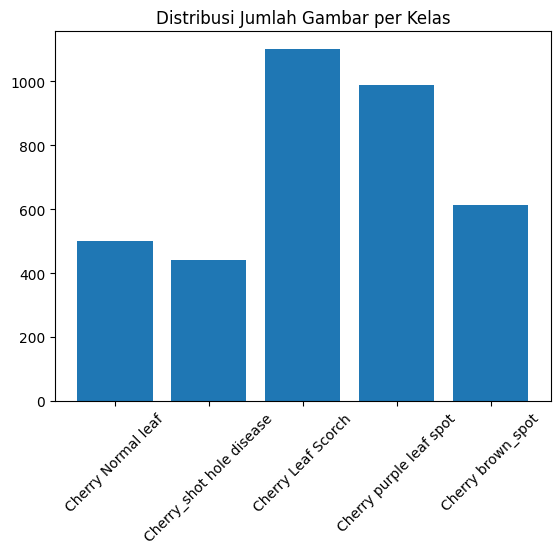

In [ ]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.show()

In [ ]:
classes = sorted(os.listdir(base_dir))
total_files = 0

print("Distribusi Data Asli")
for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        print(f"Kelas '{cls}': {count} foto")
        total_files += count

print(f"Total keseluruhan: {total_files} foto")

Distribusi Data Asli
Kelas 'Cherry Leaf Scorch': 1101 foto
Kelas 'Cherry Normal leaf': 500 foto
Kelas 'Cherry brown_spot': 614 foto
Kelas 'Cherry purple leaf spot': 987 foto
Kelas 'Cherry_shot hole disease': 440 foto
Total keseluruhan: 3642 foto


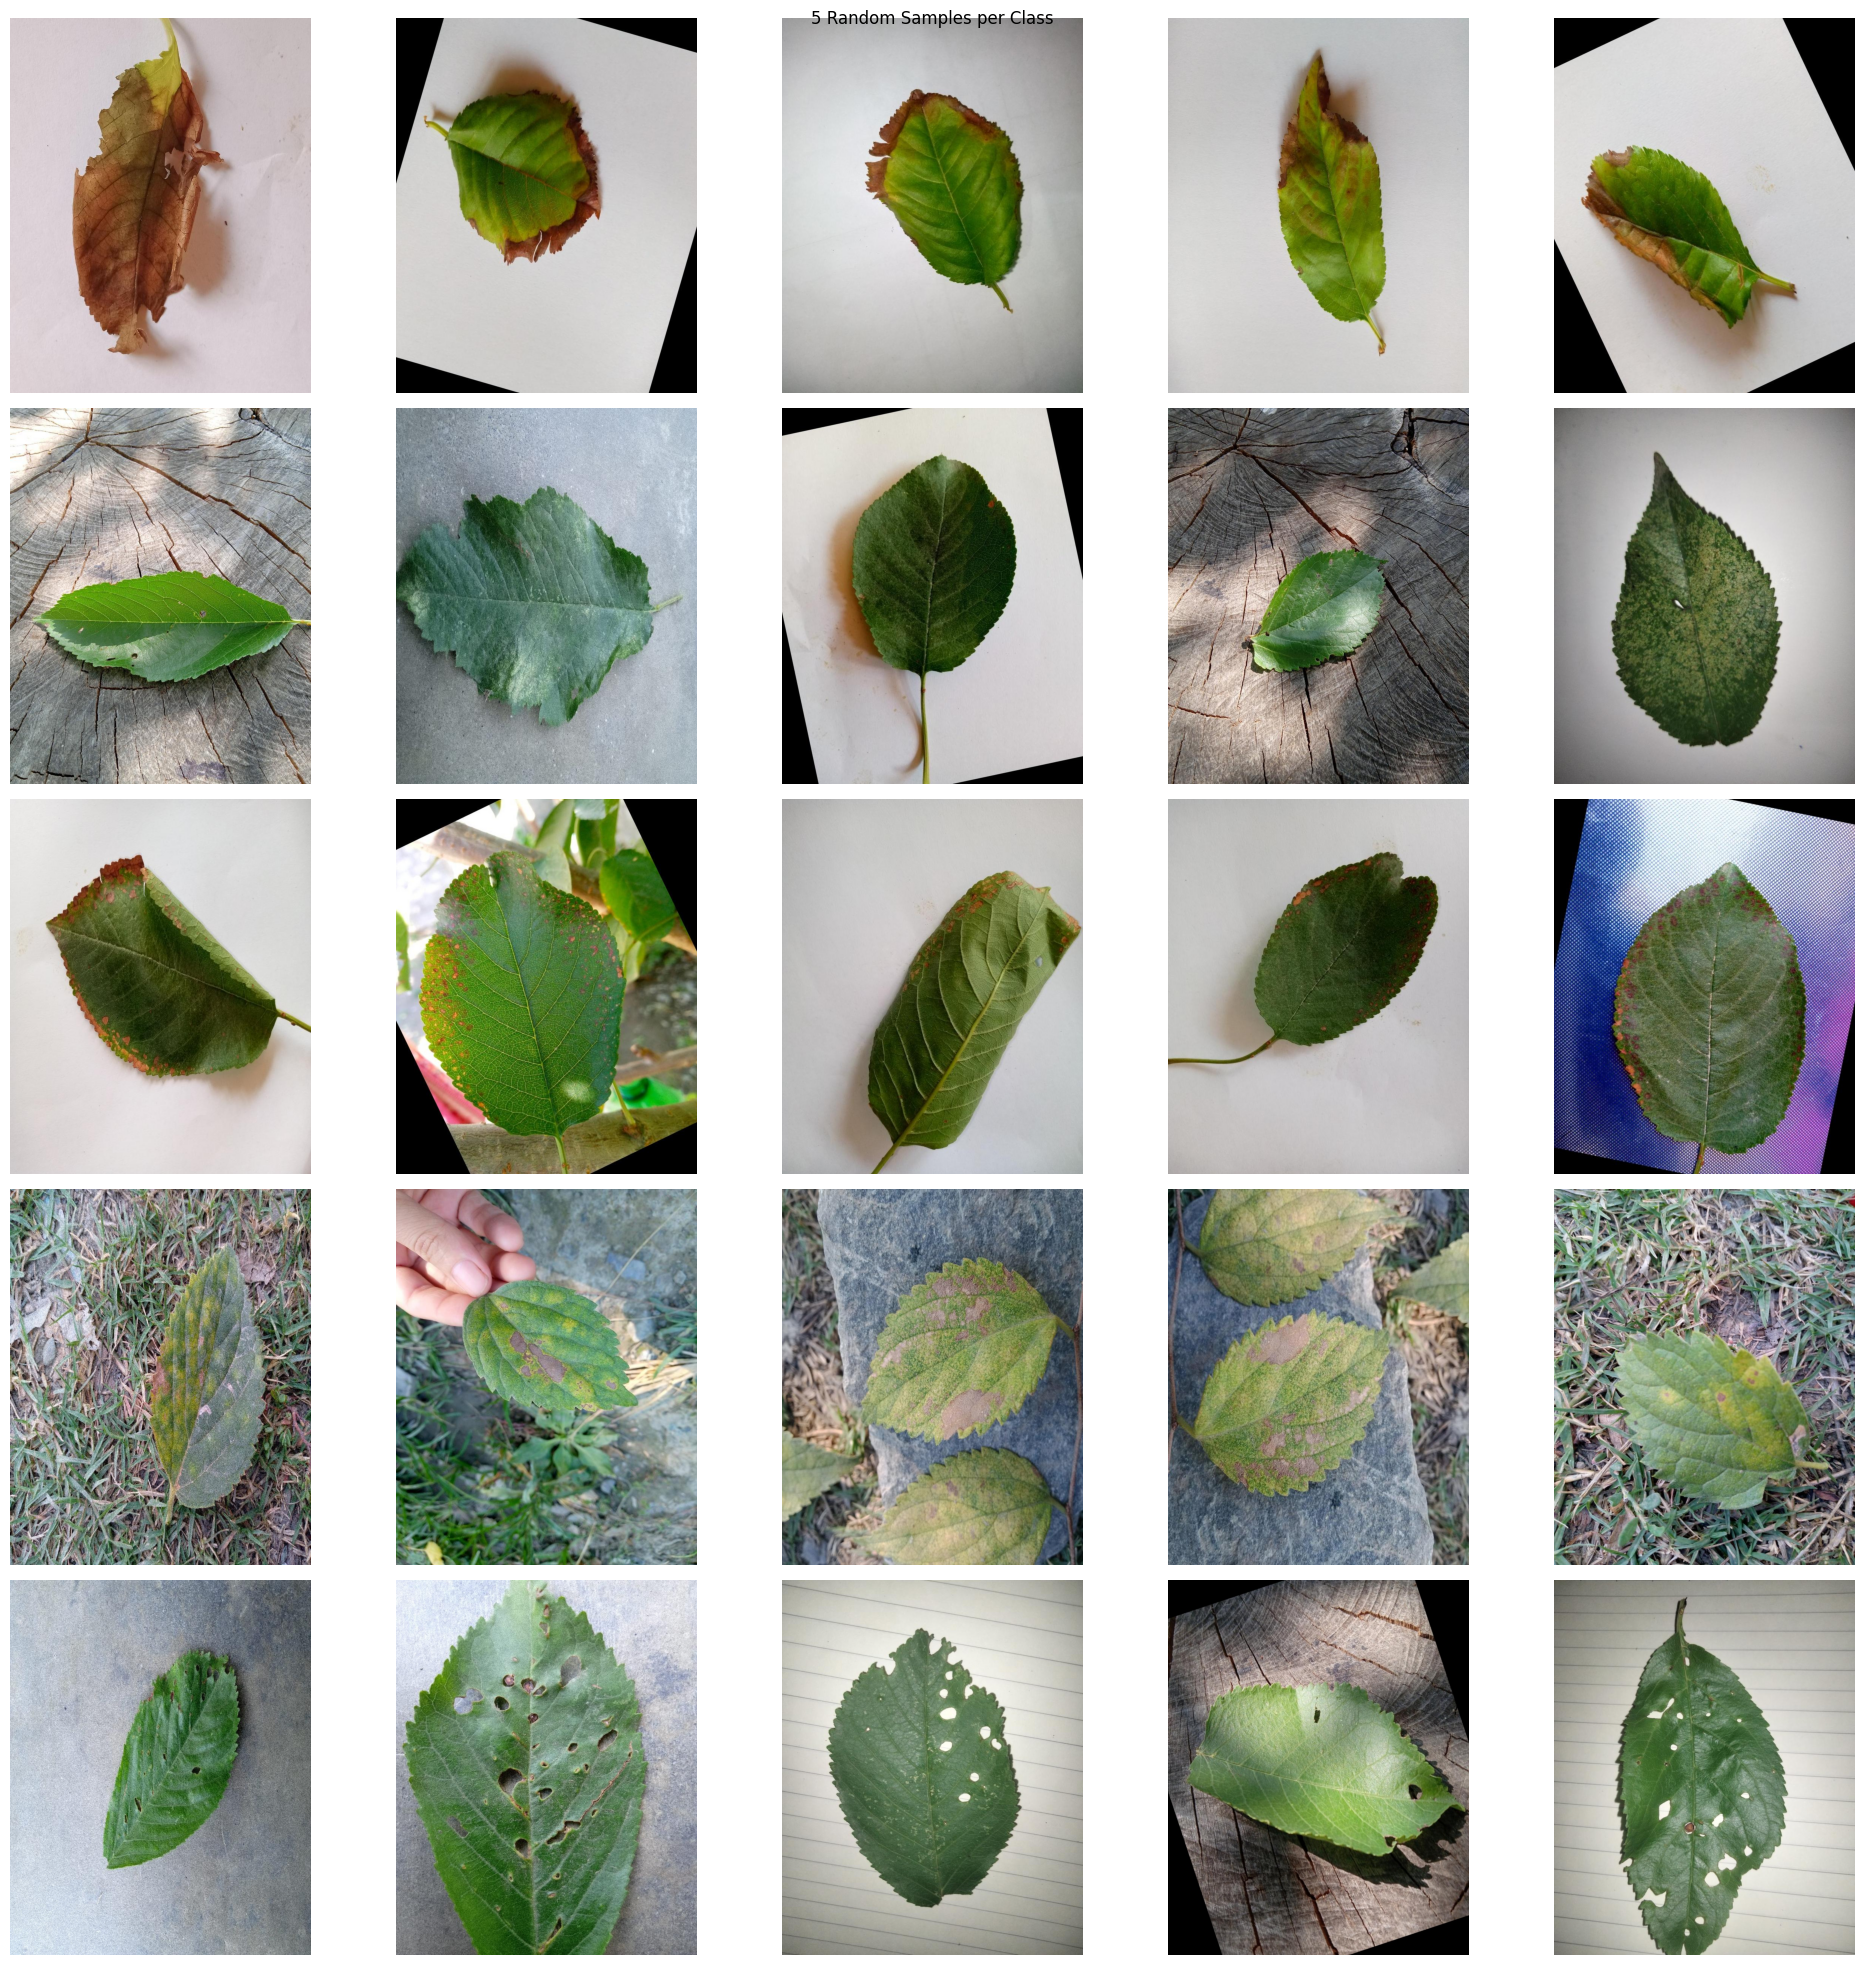

In [ ]:
import random
import math

classes = sorted(os.listdir(base_dir))
num_samples =

rows = len(classes)
cols = num_samples

plt.figure(figsize=(4*cols, 4*rows))

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    files = os.listdir(cls_path)

    if len(files) == 0:
        print(f"Empty folder: {cls}")
        continue

    selected_imgs = random.sample(files, min(num_samples, len(files)))

    for j, img_name in enumerate(selected_imgs):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Failed to load: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i*cols + j + 1)
        plt.imshow(img)

        if j == 0:
            plt.ylabel(cls, fontsize=12)

        plt.axis('off')

plt.suptitle("5 Random Samples per Class")
plt.tight_layout()
plt.show()

In [ ]:
broken_images = []

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            broken_images.append(img_path)

print(f"Jumlah gambar rusak: {len(broken_images)}")

Jumlah gambar rusak: 0


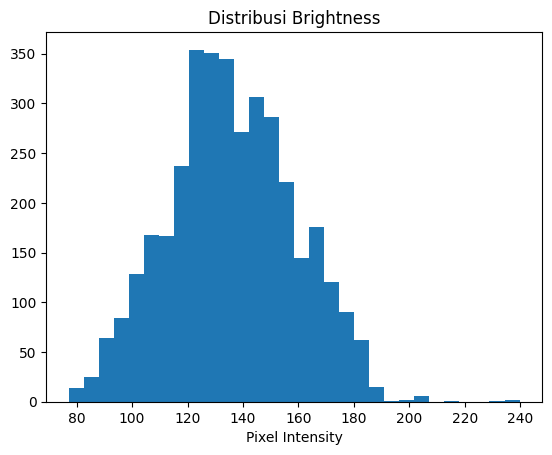

In [ ]:
pixel_means = []

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            pixel_means.append(img.mean())

plt.figure()
plt.hist(pixel_means, bins=30)
plt.title("Distribusi Brightness")
plt.xlabel("Pixel Intensity")
plt.show()

Histogram menunjukkan distribusi brightness terkonsentrasi di kisaran sekitar 110–160, dengan puncak di sekitar 120–140. Ini berarti sebagian besar gambar memiliki tingkat kecerahan sedang (tidak terlalu gelap dan terlalu terang). Distribusi relatif normal yang bentuknya seperi  lonceng, namun terdapat sedikit nilai ekstrem di sisi kanan (brightness tinggi), menandakan ada beberapa gambar yang lebih terang dibanding mayoritas.

In [ ]:
def build_alexnet_manual(num_classes):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),

        layers.Conv2D(96, (11, 11), strides=4, padding='valid', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        #layer 3
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        #layer 4
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        #layer 5
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        # Flatten
        layers.Flatten(),

        #dense layer dengan dropout 0.5
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_alexnet_manual(num_classes)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.4358 - loss: 1.3149 - val_accuracy: 0.6227 - val_loss: 0.9277
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.6941 - loss: 0.7910 - val_accuracy: 0.7125 - val_loss: 0.7043
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.7633 - loss: 0.6194 - val_accuracy: 0.8223 - val_loss: 0.4912
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.8127 - loss: 0.4813 - val_accuracy: 0.8260 - val_loss: 0.4289
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.8430 - loss: 0.4048 - val_accuracy: 0.8443 - val_loss: 0.4006
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8708 - loss: 0.3415 - val_accuracy: 0.8516 - val_loss: 0.4009
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.9042 - loss: 0.2499 - val_accuracy: 0.8883 - val_loss: 0.3214
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.8744 - loss: 0.3481 - val_accu

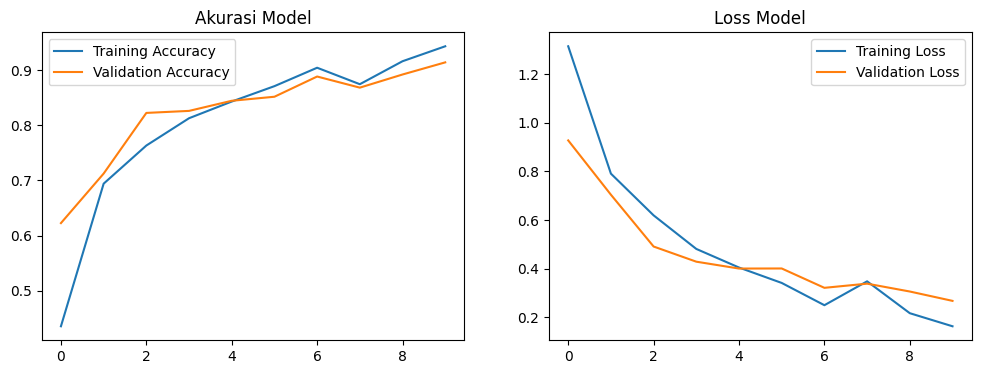

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.9180 - loss: 0.2351
Akurasi pada data Test: 91.80%


In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(10)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Akurasi Model')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss Model')
    plt.legend()
    plt.show()

plot_history(history)

test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"Akurasi pada data Test: {test_acc*100:.2f}%")

Untuk plot pertama,  training danjuga validation accuracy menunjukkan kenaikan yang sehat. Training dimulai dari 0.4 dan validation dimulai sekitar 0.5, dan sama-sama beranjak naik hingga ke 0.9. Pada epoch pertama, model belajar dengan cepat dan validation mengalami pergerakan naik turun yang tajam dari epoch 4 - 8 yang berarti bahwa model sempat mengalami ketidakstabilan.

Untuk plot kedua, training loss turun secara halus dari 1.4 menuju 0.2. Sedangkan validation loss turun juga namun mengalami lonjakan tajam di epoch ke 7. Jarak antara train loss dan val loss bisa terbilang tipis. Berarti model berhasil menerapakan pengetahuan dari data train ke data baru dengan baik

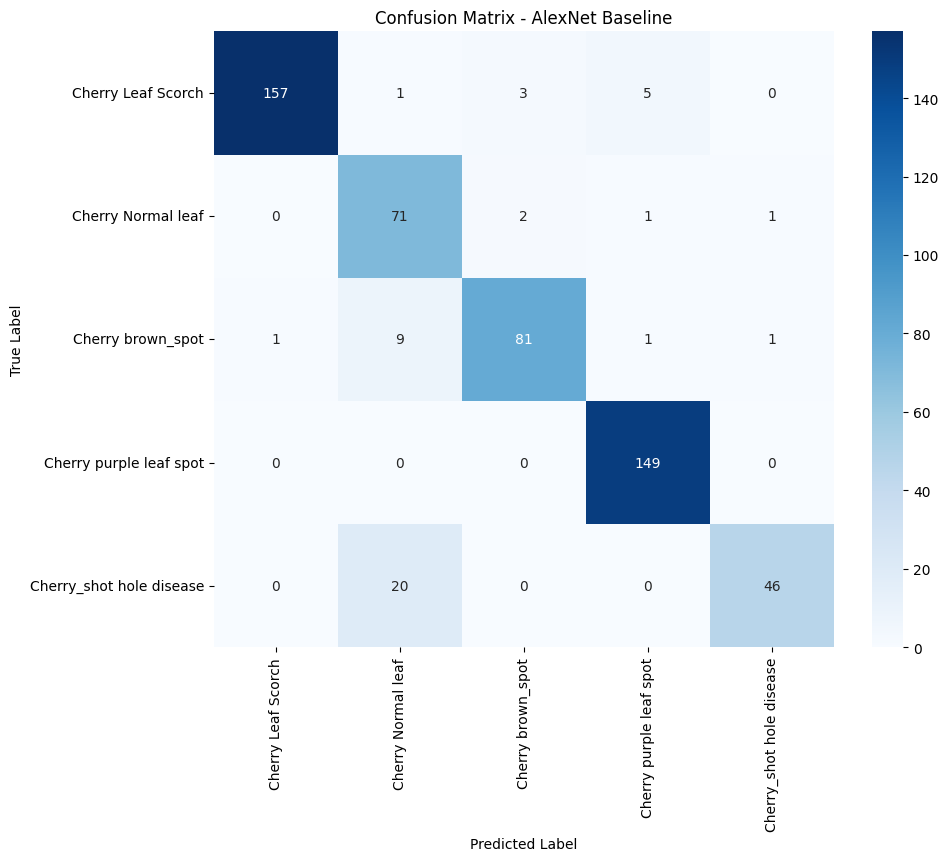

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = train_ds.class_names
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AlexNet Baseline')
plt.show()

Model cukup baik di beberapa kelas, namun terjadi misclassification antar kelas yang mirip secara visual. Kelas dengan performa terbaik adalah cherry leaf scorch, yang mengalami prediksi yang benar sebesar 157, dan hanya salah sedikit untuk brown spot dan purple leaf spot. Selanjutnya merupakan cherry purple leaf yang memprediksi semua dengan benar. Perlu diketahui bahwa kedua kelas ini merupakan kelas dengan data terbanyak, mereka. Selanjutnya adalah cherry normal leaf dengan performa menengah ia berhasil memprediksi 71 secara benar, dan terdapat sedikit kesalahan kecil pada kelas lainnya. Kelas dengan performa yang buruk terdapat Cherry brown leaf dimana ia memprediksi 81 secara benar namun sering salah mengira brown spot sebagai normal leaf. Selanjutnya ada Cherry_shot hole dimana memprediksi 46 secara benar, namun kurang bisa membedakan shot hole dengan normal leaf. Ini berarti kebingungan terbesar terjadi untuk normal dengan brown spot dan juga shot hole dengan normal.

In [ ]:
print("\n Evaluation Metrics")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


 Evaluation Metrics
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.99      0.95      0.97       166
      Cherry Normal leaf       0.70      0.95      0.81        75
       Cherry brown_spot       0.94      0.87      0.91        93
 Cherry purple leaf spot       0.96      1.00      0.98       149
Cherry_shot hole disease       0.96      0.70      0.81        66

                accuracy                           0.92       549
               macro avg       0.91      0.89      0.89       549
            weighted avg       0.93      0.92      0.92       549



Dari sini, model memiliki performa yang cukup baik dengan akurasi keseluruhan sebesar 92%, yang menunjukkan bahwa sebagian besar prediksi sudah benar. Nilai weighted F1-score sebesar 0.92 berarti  model stabil ketika mempertimbangkan distribusi jumlah data pada tiap kelas. Tapi, macro F1-score yang sedikit lebih rendah (0.89) berarti performa model belum merata di semua kelas.


Kelas Cherry Leaf Scorch dan Cherry purple leaf spot memiliki performa yang sangat tinggi, dengan nilai precision, recall, dan F1-score mendekati 1. Ini berarti model berhasil mengenal kedua kelas ini dengan baik. Kelas Cherry brown spot juga tergolong baik, meskipun recall-nya sedikit lebih rendah, yang menunjukkan masih ada beberapa data yang tidak terdeteksi dengan benar.


Namun, kelas Cherry Normal leaf dan Cherry shot hole disease menunjukkan performa yang lebih lemah. Pada Cherry Normal leaf, recall tinggi tetapi precision rendah (0.70), yang berarti model sering salah menjadiakn penyakit sebagai daun normal (false positive). Sementara itu, Cherry shot hole disease memiliki precision tinggi tetapi recall rendah (0.70), model cukup yakin untuk kelas ini, tapi banyak yang belum bisa terdeteksi (false negative).

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

In [ ]:
def build_alexnet_modified(num_classes):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        data_augmentation,

        layers.Conv2D(96, (11,11), strides=4, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(3,2),

        layers.Conv2D(256, (5,5), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(3,2),

        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(3,2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')


    ])
    return model
model = build_alexnet_modified(num_classes)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Penggunaan BatchNormalization setelah convolution (dengan use_bias=False) membantu mempercepat konvergensi dan menstabilkan distribusi fitur, pemisahan layer aktivasi membuat arsitektur lebih fleksibel, dan penggunaan padding='same' menjaga ukuran supaya tidak cepat menyusut. Flatten diganti menjadi GlobalAveragePooling2D untuk mengurangi jumlah parameter sehingga model lebih ringan dan tidak mudah overfitting, ditambah dengan Dense(512) dan Dropout(0.3) yang menjaga keseimbangan antara kapasitas model dan regularisasi.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_schedule, early_stop],
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.6270 - loss: 0.9246 - val_accuracy: 0.3095 - val_loss: 1.5221 - learning_rate: 1.0000e-04
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.7766 - loss: 0.5872 - val_accuracy: 0.3462 - val_loss: 1.5528 - learning_rate: 1.0000e-04
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.8249 - loss: 0.4359 - val_accuracy: 0.1722 - val_loss: 2.9063 - learning_rate: 1.0000e-04
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.8437 - loss: 0.3887 - val_accuracy: 0.1685 - val_loss: 3.0607 - learning_rate: 1.0000e-04
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.8697 - loss: 0.3529 - val_accuracy: 0.1905 - val_loss: 3.0529 - learning_rate: 1.0000e-04
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 150ms/step - accuracy: 0.8940 - loss: 0.2814 - val_accuracy: 0.4579 - val_loss: 1.6311 - learning_rate: 1.0000e-04
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - acc

ReduceLROnPlateau akan menurunkan learning rate sebesar faktor 0.3 ketika val_loss tidak mengalami perbaikan selama 5 epoch, sehingga model dapat melakukan fine-tuning dengan langkah yang lebih kecil saat mendekati titik optimal, sementara batas min_lr mencegah learning rate menjadi terlalu kecil. Di sisi lain, EarlyStopping dengan patience=10 akan menghentikan training jika val_loss tidak membaik dalam 10 epoch berturut-turut, serta mengembalikan bobot terbaik (restore_best_weights=True) supaya model tidak menggunakan hasil dari epoch yang sudah overfit. Kombinasi kedua callback diharapkan membuat training lebih stabil, menghemat waktu komputasi, dan menghasilkan model dengan performa generalisasi yang lebih baik.

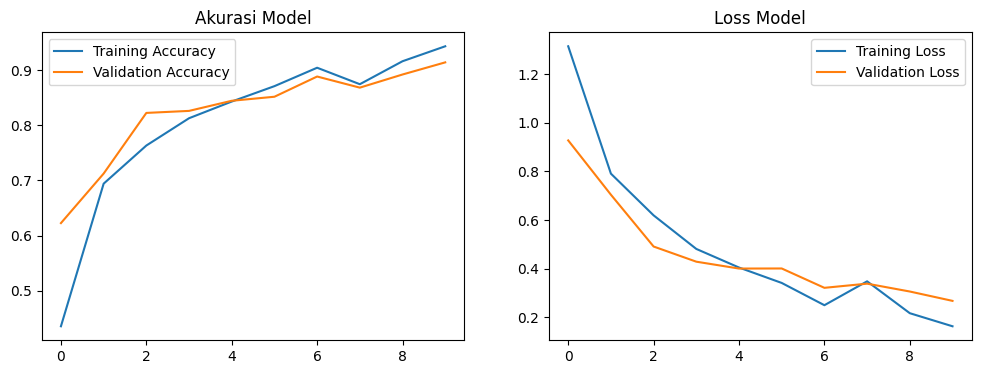

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9563 - loss: 0.1167
Akurasi pada data Test: 95.63%


In [ ]:
def plot_history(history1):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Akurasi Model')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss Model')
    plt.legend()
    plt.show()

plot_history(history1)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Akurasi pada data Test: {test_acc*100:.2f}%")

 Pada akurasi model, terlihat bahwa training accuracy meningkat tajam di awal dari 0.4 ke 0.7 lalu terus naik hingga sekitar 0.95, sementara validation accuracy juga meningkat secara konsisten dan berada sangat dekat dengan training sekitar 0.91 di akhir. Gap yang kecil antara keduanya berartu model tidak mengalami overfitting yang signifikan dan mampu melakukan generalisasi dengan baik pada data validasi.

Pada grafik loss, baik training loss maupun validation loss sama-sama menurun secara signifikan seiring bertambahnya epoch berarti bahwa model semakin baik dalam meminimalkan error. Walaupun ada terdapat sedikit naik turun pada validation loss di sekitar  epoch 5–7, secara train tetap menurun hingga mendekati 0.25, sedangkan training loss bahkan turun lebih rendah di sekitar 0.16.

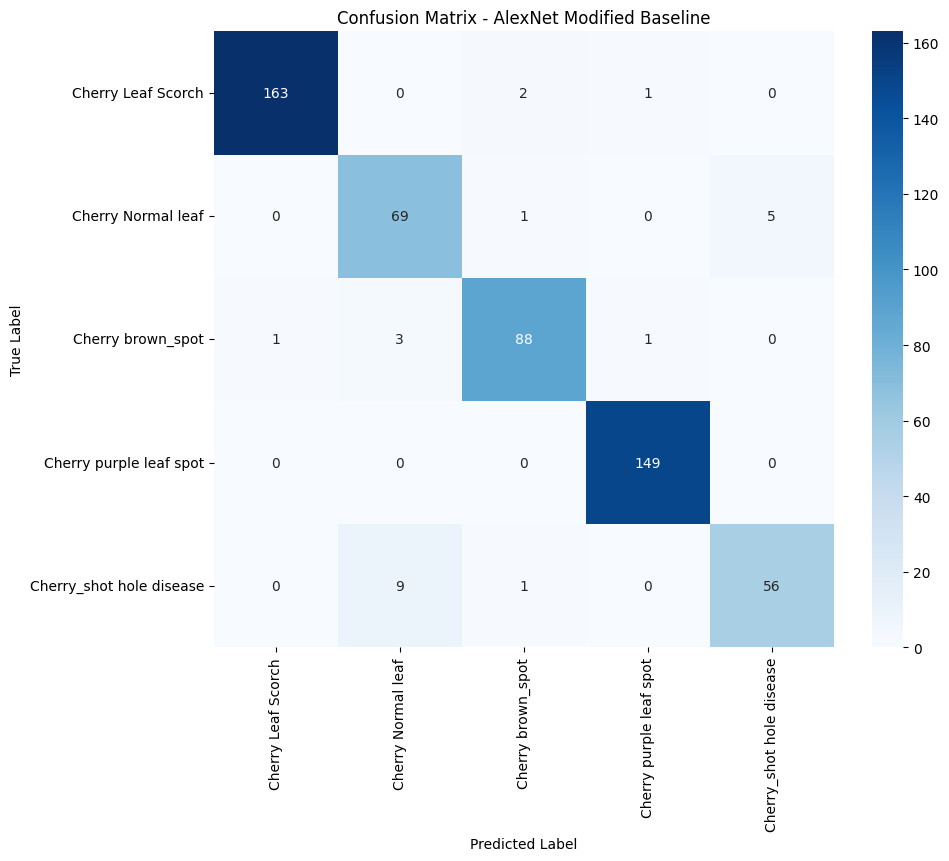

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = train_ds.class_names
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AlexNet Modified Baseline')
plt.show()

Confusion matrix disini menunjukkan bahwa model AlexNet modified memiliki performa yang sangat baik secara keseluruhan,  Kelas Cherry Leaf Scorch memiliki akurasi sangat tinggi dengan 163 prediksi benar dan hanya sedikit kesalahan dalam jumlah kecil Kelas Cherry 149 benar.

Cherry Normal leaf cukup sering salah diklasifikasikan sebagai shot hole disease (5 kasus), berarti ada kemiripan fitur di antara keduanya. Selain itu, Cherry_shot hole disease juga memiliki error yaitu 9 kali diprediksi sebagai normal leaf yang berarti model masih kebingungan untuk keduaya.

Kelas Cherry brown spot memiliki performa cukup baik, tetapi masih mengalami sedikit kebingungan dengan kelas lain seperti Normal leaf dan Leaf Scorch.

In [ ]:
print("\n Evaluation Metrics")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


 Evaluation Metrics
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.99      0.98      0.99       166
      Cherry Normal leaf       0.85      0.92      0.88        75
       Cherry brown_spot       0.96      0.95      0.95        93
 Cherry purple leaf spot       0.99      1.00      0.99       149
Cherry_shot hole disease       0.92      0.85      0.88        66

                accuracy                           0.96       549
               macro avg       0.94      0.94      0.94       549
            weighted avg       0.96      0.96      0.96       549



Dari classification report ini,  model memiliki performa yang cukup baik secara keseluruhan dengan akurasi sekitar 92%, yang berarti sebagian besar prediksi sudah sesuai dengan label sebenarnya. Nilai weighted average F1-score sebesar 0.92 juga menunjukkan bahwa performa model cukup stabil.

Kelas Cherry Leaf Scorch dan Cherry purple leaf spot memiliki nilai precision, recall, dan F1-score yang tinggi. Hal ini menunjukkan bahwa model mampu mengenali kedua kelas tersebut dengan akurat dan konsisten. Cherry brown spot juga memiliki performa yang cukup baik, meskipun recall sedikit lebih rendah yang menandakan masih ada beberapa data yang tidak terdeteksi.

Tapi, performa model masih kurang baik pada beberapa kelas seperti Cherry Normal leaf dan Cherry shot hole disease yang memiliki F1-score lebih rendah, yaitu sekitar 0.88. Pada Cherry Normal leaf, recall tinggi tetapi precision rendah, yang berarti model sering salah mengklasifikasikan kelas lain sebagai daun normal. Sementara itu, pada Cherry shot hole disease, precision tinggi tetapi recall rendah, yang berarti bahwa meskipun prediksi yang diberikan cukup akurat, masih banyak data yang seharusnya termasuk kelas ini tidak terdeteksi.


Dari classification report, dapat terlihat bahwa yang modified lebih baik dibandingkan baseline. Modified berhasil meningkatkan f1-score dari 0.92 menjadi 0.96 dan macro dari 0.89- 0.94.

Untuk kelas Cherry Normal leaf dan cherry shot hole, f1-score meningkat dari 0.81 menjadi 0.88. Berarti model modified lebih mampu membedakan kelas yang sebelumnya sulit diklasifikasikan. Cherry brown spot juga mengalami peningkatan dari 0.91 menjadi 0.95. Untuk kelas yang sejak awal sudah memiliki performa tinggi seperti Cherry Leaf Scorch dan Cherry purple leaf spot, peningkatan tetap terjadi meskipun tidak terlalu besar, dengan f1-score mendekati sempurna (0.99).

Model modified menunjukkan kemampuan generalisasi yang lebih baik dibandingkan baseline. Peningkatan tidak hanya terjadi pada kelas yang sudah mudah dikenali, tetapi juga pada kelas yang sebelumnya menjadi kelemahan model. Berarti model yang dimodifikasi berhasil membuat model lebih stabil dalam mengklasifikasikan penyakit.

Saran saya untuk memilih yang modified model karena sudah dalam kondisi yang baik. Namun, dapat dicoba lagi dengan menambah data sehingga kondisi tidaklah imbalanced. Selain itu juga dapat dicoba variasi learning rate dan early stopping dan melakukan data augmentasi yang berfokus lebih kepada peningkatan kualitas dan variasi data.


Link Youtube: https://youtu.be/VI3MMJdIDv0